Poker Hands Classification 
Name: Kavin Ezhilan
Course: ITCS 3156
Models: KNN, Naive Bayes

The goal of of this project is classify poker hands using the 2 aformentioned algorthms 
Each hand has 5 total cards denoted by a suit and rank (Spades, 2) and the task is to predict the category of the hand (full house, flush, pair, etc)

Data Preprcessing

In [1]:
!pip install ucimlrepo

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)


In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd 

# Load dataset
poker_hand = fetch_ucirepo(id=158)

# Features and target
X = poker_hand.data.features
y = poker_hand.data.targets.squeeze()
df = X.copy()
df['CLASS'] = y

# balanced sampling
balanced = df.groupby('CLASS', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=42)
)

X_small = balanced.drop('CLASS', axis=1)
y_small = balanced['CLASS']

print(X_small.shape)
print(y_small.value_counts())
# Quick check
print(X.head())
print(y.head())
print(X.shape)
print(y.value_counts())

(3761, 10)
CLASS
0    500
1    500
2    500
3    500
4    500
5    500
6    500
7    236
8     17
9      8
Name: count, dtype: int64
   S1  C1  S2  C2  S3  C3  S4  C4  S5  C5
0   1  10   1  11   1  13   1  12   1   1
1   2  11   2  13   2  10   2  12   2   1
2   3  12   3  11   3  13   3  10   3   1
3   4  10   4  11   4   1   4  13   4  12
4   4   1   4  13   4  12   4  11   4  10
0    9
1    9
2    9
3    9
4    9
Name: CLASS, dtype: int64
(1025010, 10)
CLASS
0    513702
1    433097
2     48828
3     21634
4      3978
5      2050
6      1460
7       236
8        17
9         8
Name: count, dtype: int64


C:\Users\Kavin Ezhilan\AppData\Local\Temp\ipykernel_25616\2858328544.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced = df.groupby('CLASS', group_keys=False).apply(


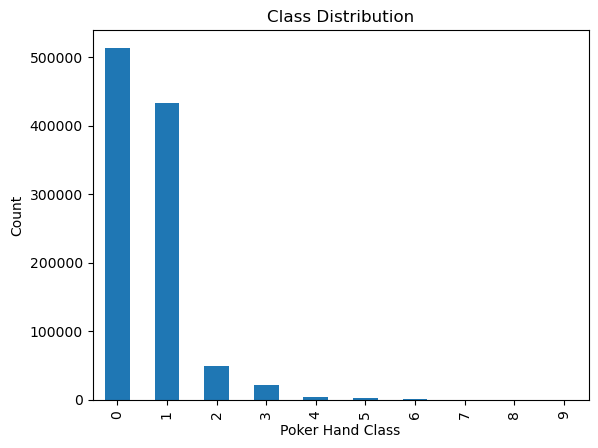

In [3]:
import matplotlib.pyplot as plt

y.value_counts().sort_index().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Poker Hand Class")
plt.ylabel("Count")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)


scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

KNN Algorithm

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [6]:
from sklearn.metrics import accuracy_score, classification_report
y_pred_knn = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.3333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.38      0.35       100
           1       0.22      0.19      0.20       100
           2       0.21      0.22      0.22       100
           3       0.15      0.13      0.14       100
           4       0.28      0.35      0.31       100
           5       0.77      0.99      0.87       100
           6       0.24      0.20      0.22       100
           7       0.24      0.11      0.15        47
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         2

    accuracy                           0.33       753
   macro avg       0.24      0.26      0.25       753
weighted avg       0.31      0.33      0.32       753



c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


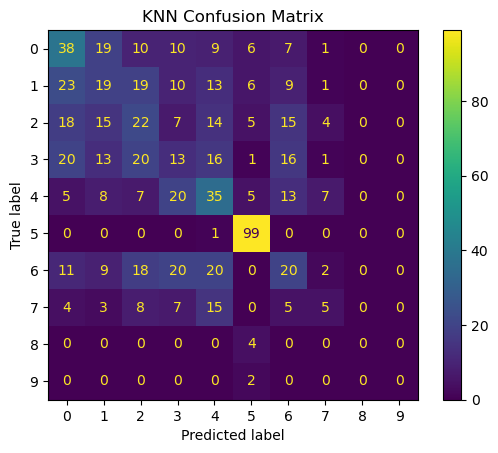

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN Confusion Matrix")
plt.show()

In [8]:
for k in [3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = knn.score(X_test_scaled, y_test)
    print(f"K={k}, Accuracy={acc}")

K=3, Accuracy=0.33200531208499334
K=5, Accuracy=0.3333333333333333
K=7, Accuracy=0.33598937583001326
K=9, Accuracy=0.3399734395750332


Naive Bayes Algorithm

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

In [10]:
from sklearn.naive_bayes import CategoricalNB

nb = CategoricalNB()
nb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [11]:
from sklearn.metrics import accuracy_score, classification_report
y_pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.19389110225763612

Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.17      0.19       100
           1       0.21      0.21      0.21       100
           2       0.12      0.09      0.10       100
           3       0.15      0.14      0.15       100
           4       0.24      0.48      0.32       100
           5       0.24      0.25      0.24       100
           6       0.14      0.12      0.13       100
           7       0.00      0.00      0.00        47
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         2

    accuracy                           0.19       753
   macro avg       0.13      0.15      0.13       753
weighted avg       0.17      0.19      0.18       753



c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


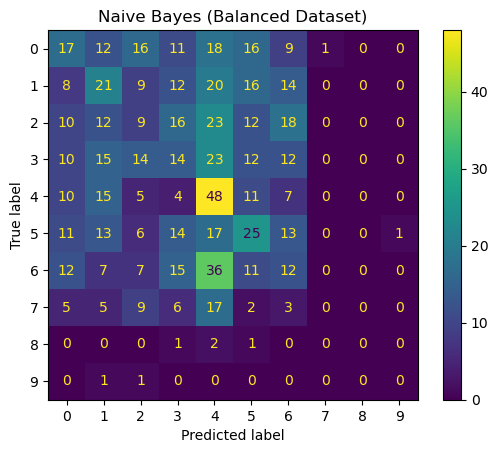

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naive Bayes (Balanced Dataset)")
plt.show()

Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    multi_class='multinomial'
)

lr.fit(X_train_scaled, y_train)

c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'multinomial'


In [14]:
from sklearn.metrics import accuracy_score, classification_report
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.150066401062417

Classification Report:
               precision    recall  f1-score   support

           0       0.14      0.22      0.17       100
           1       0.12      0.08      0.10       100
           2       0.15      0.16      0.16       100
           3       0.06      0.08      0.07       100
           4       0.19      0.24      0.21       100
           5       0.29      0.22      0.25       100
           6       0.14      0.13      0.14       100
           7       0.00      0.00      0.00        47
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         2

    accuracy                           0.15       753
   macro avg       0.11      0.11      0.11       753
weighted avg       0.15      0.15      0.14       753



c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kavin Ezhilan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


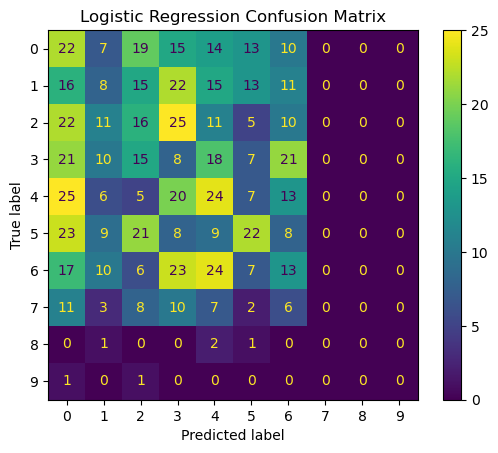

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()